<a href="https://www.kaggle.com/code/suraiyaetu/mci-detection?scriptVersionId=342440799" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [70]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset/integrated_eeg_dataset.npz


In [71]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print("\nFOLDER:", dirname)
    for filename in filenames:
        print("   ", filename)


FOLDER: /kaggle/input

FOLDER: /kaggle/input/datasets

FOLDER: /kaggle/input/datasets/codingyodha

FOLDER: /kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset
    integrated_eeg_dataset.npz


In [72]:
import numpy as np

file_path = "/kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset/integrated_eeg_dataset.npz"

data = np.load(file_path, allow_pickle=True)

print("Files inside the NPZ:")
print(data.files)

Files inside the NPZ:
['X_raw', 'y_labels', 'X_features']


In [73]:
import numpy as np

file_path = "/kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset/integrated_eeg_dataset.npz"

data = np.load(file_path)

print("Files inside the NPZ:", data.files)

print("\nX_raw:")
print("Shape:", data["X_raw"].shape)
print("Data type:", data["X_raw"].dtype)

print("\ny_labels:")
print("Shape:", data["y_labels"].shape)
print("Data type:", data["y_labels"].dtype)
print("Unique labels:", np.unique(data["y_labels"]))

print("\nX_features:")
print("Shape:", data["X_features"].shape)
print("Data type:", data["X_features"].dtype)

Files inside the NPZ: ['X_raw', 'y_labels', 'X_features']

X_raw:
Shape: (101916, 128, 19)
Data type: float64

y_labels:
Shape: (101916, 3)
Data type: <U32
Unique labels: ['-1' '0' '0.0' '1' '1.0' '10' '10.0' '11' '11.0' '12' '12.0' '13' '13.0'
 '14' '14.0' '15' '15.0' '16' '16.0' '17' '17.0' '18' '18.0' '19' '19.0'
 '2' '20' '20.0' '21' '21.0' '22' '22.0' '23' '23.0' '24' '25' '26' '27'
 '28' '29' '30' '31' '32' '33' '34' '35' '36' '37' '38' '39' '40' '41'
 '42' '43' '44' '45' '46' '47' '48' '49' '50' '51' '52' '53' '54' '55'
 '56' '57' '58' '59' '60' '61' '62' '63' '64' '65' '66' '67' '68' '69'
 '70' '71' '72' '73' '74' '75' '76' '77' '78' '79' '80' '81' '82' '83'
 '84' '85' '86' '87' '88' '89' '90' '91' '92' 'AD-Auditory' 'ADFSU'
 'ADFTD' 'ADSZ' 'APAVA-19']

X_features:
Shape: (101916, 76)
Data type: float64


In [74]:
import numpy as np

# Load dataset
data = np.load(
    "/kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset/integrated_eeg_dataset.npz",
    allow_pickle=True
)

X_raw = data["X_raw"]
y_labels = data["y_labels"]
X_features = data["X_features"]

print("X_raw shape:", X_raw.shape)
print("y_labels shape:", y_labels.shape)
print("X_features shape:", X_features.shape)

# Look at the first 10 rows of labels
print("\nFirst 10 rows of y_labels:")
print(y_labels[:10])

X_raw shape: (101916, 128, 19)
y_labels shape: (101916, 3)
X_features shape: (101916, 76)

First 10 rows of y_labels:
[['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']]


In [75]:
import numpy as np

# Check unique values for each label column
for i in range(y_labels.shape[1]):
    unique_values = np.unique(y_labels[:, i])

    print(f"\nColumn {i}")
    print("Number of unique values:", len(unique_values))
    print("Unique values:")
    print(unique_values[:150])

# Show a few rows with all 3 columns
print("\nSample labels:")
for row in y_labels[:20]:
    print(row)


Column 0
Number of unique values: 6
Unique values:
['-1' '0' '0.0' '1' '1.0' '2']

Column 1
Number of unique values: 97
Unique values:
['10' '10.0' '11' '11.0' '12' '12.0' '13' '13.0' '14' '14.0' '15' '15.0'
 '16' '16.0' '17' '17.0' '18' '18.0' '19' '19.0' '20' '20.0' '21' '21.0'
 '22' '22.0' '23' '23.0' '24' '25' '26' '27' '28' '29' '30' '31' '32' '33'
 '34' '35' '36' '37' '38' '39' '40' '41' '42' '43' '44' '45' '46' '47'
 '48' '49' '50' '51' '52' '53' '54' '55' '56' '57' '58' '59' '60' '61'
 '62' '63' '64' '65' '66' '67' '68' '69' '70' '71' '72' '73' '74' '75'
 '76' '77' '78' '79' '80' '81' '82' '83' '84' '85' '86' '87' '88' '89'
 '90' '91' '92']

Column 2
Number of unique values: 5
Unique values:
['AD-Auditory' 'ADFSU' 'ADFTD' 'ADSZ' 'APAVA-19']

Sample labels:
['0' '10' 'AD-Auditory']
['0' '10' 'AD-Auditory']
['0' '10' 'AD-Auditory']
['0' '10' 'AD-Auditory']
['0' '10' 'AD-Auditory']
['0' '10' 'AD-Auditory']
['0' '10' 'AD-Auditory']
['0' '10' 'AD-Auditory']
['0' '10' 'AD-Auditory']

In [76]:
import pandas as pd
import numpy as np

# Create label dataframe
df = pd.DataFrame(
    y_labels,
    columns=["clinical_label", "subject_id", "dataset"]
)

# Clean clinical labels
df["clinical_label"] = df["clinical_label"].astype(str)

print("Clinical label distribution:")
print(df["clinical_label"].value_counts().sort_index())

print("\nClinical label vs dataset:")
print(
    pd.crosstab(
        df["clinical_label"],
        df["dataset"]
    )
)

print("\nClinical label vs Subject ID:")
print(
    df.groupby("clinical_label")["subject_id"]
      .nunique()
)

Clinical label distribution:
clinical_label
-1      1179
0      31892
0.0     1809
1      26056
1.0     2547
2      38433
Name: count, dtype: int64

Clinical label vs dataset:
dataset         AD-Auditory  ADFSU  ADFTD  ADSZ  APAVA-19
clinical_label                                           
-1                     1179      0      0     0         0
0                      7074    360  24098   360         0
0.0                       0      0      0     0      1809
1                      7074   2130  16579   273         0
1.0                       0      0      0     0      2547
2                     15327      0  23106     0         0

Clinical label vs Subject ID:
clinical_label
-1      1
0      56
0.0     7
1      79
1.0     7
2      27
Name: subject_id, dtype: int64


In [77]:
# Clean clinical labels

df["clinical_label_clean"] = (
    pd.to_numeric(df["clinical_label"], errors="coerce")
)

print("Cleaned clinical label distribution:")
print(
    df["clinical_label_clean"]
    .value_counts()
    .sort_index()
)

print("\nCleaned labels:")
print(
    sorted(df["clinical_label_clean"].dropna().unique())
)

Cleaned clinical label distribution:
clinical_label_clean
-1.0     1179
 0.0    33701
 1.0    28603
 2.0    38433
Name: count, dtype: int64

Cleaned labels:
[np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0)]


In [78]:
# Check clinical label distribution by dataset

print(
    pd.crosstab(
        df["clinical_label_clean"],
        df["dataset"],
        margins=True
    )
)

print("\nSubject IDs for each clinical label:")

for label in sorted(df["clinical_label_clean"].dropna().unique()):
    subjects = df.loc[
        df["clinical_label_clean"] == label,
        "subject_id"
    ].unique()

    print(f"\nLabel {label}:")
    print("Number of subjects:", len(subjects))
    print("Subjects:", subjects[:20])

dataset               AD-Auditory  ADFSU  ADFTD  ADSZ  APAVA-19     All
clinical_label_clean                                                   
-1.0                         1179      0      0     0         0    1179
 0.0                         7074    360  24098   360      1809   33701
 1.0                         7074   2130  16579   273      2547   28603
 2.0                        15327      0  23106     0         0   38433
 All                        30654   2490  63783   633      4356  101916

Subject IDs for each clinical label:

Label -1.0:
Number of subjects: 1
Subjects: ['13']

Label 0.0:
Number of subjects: 63
Subjects: ['10' '12' '22' '25' '26' '31' '81' '82' '83' '84' '85' '86' '87' '88'
 '89' '90' '91' '92' '37' '38']

Label 1.0:
Number of subjects: 86
Subjects: ['17' '18' '19' '27' '28' '32' '10' '11' '12' '13' '14' '15' '16' '20'
 '21' '22' '23' '24' '25' '26']

Label 2.0:
Number of subjects: 27
Subjects: ['11' '14' '15' '16' '20' '21' '23' '24' '29' '30' '33' '34' '35'

In [79]:
# Check exactly which clinical labels occur for each dataset
for dataset_name in df["dataset"].unique():

    print("\n" + "=" * 60)
    print("DATASET:", dataset_name)
    print("=" * 60)

    temp = df[df["dataset"] == dataset_name]

    print(
        temp.groupby("clinical_label_clean")["subject_id"]
        .nunique()
        .sort_index()
    )

# Show subject-level label consistency
subject_label = (
    df.groupby(["dataset", "subject_id"])["clinical_label_clean"]
      .unique()
      .reset_index()
)

print(subject_label.head(50).to_string(index=False))


DATASET: AD-Auditory
clinical_label_clean
-1.0     1
 0.0     6
 1.0     6
 2.0    13
Name: subject_id, dtype: int64

DATASET: ADFSU
clinical_label_clean
0.0    12
1.0    71
Name: subject_id, dtype: int64

DATASET: ADFTD
clinical_label_clean
0.0    29
1.0    23
2.0    27
Name: subject_id, dtype: int64

DATASET: ADSZ
clinical_label_clean
0.0    24
1.0    15
Name: subject_id, dtype: int64

DATASET: APAVA-19
clinical_label_clean
0.0    7
1.0    7
Name: subject_id, dtype: int64
    dataset subject_id clinical_label_clean
AD-Auditory         10                [0.0]
AD-Auditory         11                [2.0]
AD-Auditory         12                [0.0]
AD-Auditory         13               [-1.0]
AD-Auditory         14                [2.0]
AD-Auditory         15                [2.0]
AD-Auditory         16                [2.0]
AD-Auditory         17                [1.0]
AD-Auditory         18                [1.0]
AD-Auditory         19                [1.0]
AD-Auditory         20              

In [80]:
# Isolate AD-Auditory dataset

ad_auditory = df[df["dataset"] == "AD-Auditory"].copy()

print("AD-Auditory samples:", len(ad_auditory))

print("\nClinical label distribution:")
print(ad_auditory["clinical_label_clean"].value_counts().sort_index())

print("\nSubject-level labels:")
print(
    ad_auditory[
        ["subject_id", "clinical_label_clean"]
    ]
    .drop_duplicates()
    .sort_values("subject_id")
    .to_string(index=False)
)

AD-Auditory samples: 30654

Clinical label distribution:
clinical_label_clean
-1.0     1179
 0.0     7074
 1.0     7074
 2.0    15327
Name: count, dtype: int64

Subject-level labels:
subject_id  clinical_label_clean
        10                   0.0
        11                   2.0
        12                   0.0
        13                  -1.0
        14                   2.0
        15                   2.0
        16                   2.0
        17                   1.0
        18                   1.0
        19                   1.0
        20                   2.0
        21                   2.0
        22                   0.0
        23                   2.0
        24                   2.0
        25                   0.0
        26                   0.0
        27                   1.0
        28                   1.0
        29                   2.0
        30                   2.0
        31                   0.0
        32                   1.0
        33               

In [81]:
# ============================================================
# AD-Auditory: Subject-wise sample count
# ============================================================

ad_indices = np.where(y_labels[:, 2] == "AD-Auditory")[0]

ad_subjects = y_labels[ad_indices, 1]
ad_labels = df.loc[ad_indices, "clinical_label_clean"].values

subject_summary = pd.DataFrame({
    "subject_id": ad_subjects,
    "clinical_label": ad_labels
})

subject_summary = (
    subject_summary
    .groupby(["subject_id", "clinical_label"])
    .size()
    .reset_index(name="samples")
)

print(subject_summary.to_string(index=False))

print("\nTotal subjects:", len(subject_summary))
print("Total samples:", subject_summary["samples"].sum())

subject_id  clinical_label  samples
        10             0.0     1179
        11             2.0     1179
        12             0.0     1179
        13            -1.0     1179
        14             2.0     1179
        15             2.0     1179
        16             2.0     1179
        17             1.0     1179
        18             1.0     1179
        19             1.0     1179
        20             2.0     1179
        21             2.0     1179
        22             0.0     1179
        23             2.0     1179
        24             2.0     1179
        25             0.0     1179
        26             0.0     1179
        27             1.0     1179
        28             1.0     1179
        29             2.0     1179
        30             2.0     1179
        31             0.0     1179
        32             1.0     1179
        33             2.0     1179
        34             2.0     1179
        35             2.0     1179

Total subjects: 26
Total sa

In [82]:
# Check whether every subject has only one clinical label

label_per_subject = (
    subject_summary
    .groupby("subject_id")["clinical_label"]
    .nunique()
)

print("Subjects with multiple labels:",
      (label_per_subject > 1).sum())

Subjects with multiple labels: 0


In [83]:
# Check whether each subject has only one clinical label

label_per_subject = (
    subject_summary
    .groupby("subject_id")["clinical_label"]
    .nunique()
)

print(
    "Subjects with multiple labels:",
    (label_per_subject > 1).sum()
)

Subjects with multiple labels: 0


In [84]:
# ============================================================
# AD-Auditory: Subjects grouped by clinical label
# ============================================================

for label in sorted(subject_summary["clinical_label"].unique()):

    subjects = (
        subject_summary[
            subject_summary["clinical_label"] == label
        ]["subject_id"]
        .tolist()
    )

    print(f"\nClinical Label {label}")
    print("Number of subjects:", len(subjects))
    print("Subjects:", subjects)


Clinical Label -1.0
Number of subjects: 1
Subjects: ['13']

Clinical Label 0.0
Number of subjects: 6
Subjects: ['10', '12', '22', '25', '26', '31']

Clinical Label 1.0
Number of subjects: 6
Subjects: ['17', '18', '19', '27', '28', '32']

Clinical Label 2.0
Number of subjects: 13
Subjects: ['11', '14', '15', '16', '20', '21', '23', '24', '29', '30', '33', '34', '35']


In [85]:
# Check the raw labels and dataset for each AD-Auditory subject

ad_subject_info = (
    pd.DataFrame({
        "subject_id": y_labels[ad_indices, 1],
        "clinical_label": df.loc[ad_indices, "clinical_label_clean"].values,
        "dataset": y_labels[ad_indices, 2]
    })
    .drop_duplicates()
    .sort_values("subject_id")
)

print(ad_subject_info.to_string(index=False))

subject_id  clinical_label     dataset
        10             0.0 AD-Auditory
        11             2.0 AD-Auditory
        12             0.0 AD-Auditory
        13            -1.0 AD-Auditory
        14             2.0 AD-Auditory
        15             2.0 AD-Auditory
        16             2.0 AD-Auditory
        17             1.0 AD-Auditory
        18             1.0 AD-Auditory
        19             1.0 AD-Auditory
        20             2.0 AD-Auditory
        21             2.0 AD-Auditory
        22             0.0 AD-Auditory
        23             2.0 AD-Auditory
        24             2.0 AD-Auditory
        25             0.0 AD-Auditory
        26             0.0 AD-Auditory
        27             1.0 AD-Auditory
        28             1.0 AD-Auditory
        29             2.0 AD-Auditory
        30             2.0 AD-Auditory
        31             0.0 AD-Auditory
        32             1.0 AD-Auditory
        33             2.0 AD-Auditory
        34             2.

In [86]:
# ============================================================
# STEP: Subject-level label distribution for every dataset
# ============================================================

subject_level = (
    df.groupby(
        ["dataset", "subject_id", "clinical_label_clean"]
    )
    .size()
    .reset_index(name="samples")
)

print("Total unique subject-dataset combinations:",
      len(subject_level))

print("\nSubject count by dataset and clinical label:")
print(
    subject_level
    .groupby(["dataset", "clinical_label_clean"])["subject_id"]
    .nunique()
    .unstack(fill_value=0)
)

Total unique subject-dataset combinations: 241

Subject count by dataset and clinical label:
clinical_label_clean  -1.0   0.0   1.0   2.0
dataset                                     
AD-Auditory              1     6     6    13
ADFSU                    0    12    71     0
ADFTD                    0    29    23    27
ADSZ                     0    24    15     0
APAVA-19                 0     7     7     0


In [87]:
# ============================================================
# STEP: Check whether label meanings are consistent
# across datasets
# ============================================================

for dataset_name in sorted(df["dataset"].unique()):

    temp = subject_level[
        subject_level["dataset"] == dataset_name
    ]

    print("\n" + "=" * 60)
    print(dataset_name)
    print("=" * 60)

    print(
        temp.groupby("clinical_label_clean")["subject_id"]
        .nunique()
        .sort_index()
    )


AD-Auditory
clinical_label_clean
-1.0     1
 0.0     6
 1.0     6
 2.0    13
Name: subject_id, dtype: int64

ADFSU
clinical_label_clean
0.0    12
1.0    71
Name: subject_id, dtype: int64

ADFTD
clinical_label_clean
0.0    29
1.0    23
2.0    27
Name: subject_id, dtype: int64

ADSZ
clinical_label_clean
0.0    24
1.0    15
Name: subject_id, dtype: int64

APAVA-19
clinical_label_clean
0.0    7
1.0    7
Name: subject_id, dtype: int64


In [88]:
# ============================================================
# STEP: Search dataset metadata for possible MCI information
# ============================================================

print("y_labels shape:", y_labels.shape)

# Show all unique combinations of:
# clinical label + dataset

label_dataset = (
    df[["clinical_label_clean", "dataset"]]
    .drop_duplicates()
    .sort_values(["dataset", "clinical_label_clean"])
)

print("\nUnique label-dataset combinations:")
print(label_dataset.to_string(index=False))

y_labels shape: (101916, 3)

Unique label-dataset combinations:
 clinical_label_clean     dataset
                 -1.0 AD-Auditory
                  0.0 AD-Auditory
                  1.0 AD-Auditory
                  2.0 AD-Auditory
                  0.0       ADFSU
                  1.0       ADFSU
                  0.0       ADFTD
                  1.0       ADFTD
                  2.0       ADFTD
                  0.0        ADSZ
                  1.0        ADSZ
                  0.0    APAVA-19
                  1.0    APAVA-19


In [89]:
# ============================================================
# STEP: Check whether X_features contain missing/infinite values
# ============================================================

print("NaN values:", np.isnan(X_features).sum())
print("Infinite values:", np.isinf(X_features).sum())

print("\nFeature statistics:")
print(
    pd.DataFrame(X_features).describe().T.head(10)
)

NaN values: 0
Infinite values: 0

Feature statistics:
      count      mean        std         min       25%           50%  \
0  101916.0  0.227165  11.711674 -109.150455 -0.000028 -1.673054e-06   
1  101916.0 -0.705547  11.663422 -259.160844 -0.000030 -2.088261e-06   
2  101916.0 -1.296609  14.376640 -398.069887 -0.000028 -1.759820e-06   
3  101916.0 -0.404245  10.842506 -286.054902 -0.000026 -1.074043e-06   
4  101916.0  0.305670  10.166684 -121.869826 -0.000025 -1.133152e-06   
5  101916.0 -0.083936   9.599681  -99.022873 -0.000025 -1.020211e-06   
6  101916.0 -0.912761   9.742406 -391.596831 -0.000027 -1.420649e-06   
7  101916.0 -0.341439   6.158083 -129.110428 -0.000020  1.239270e-06   
8  101916.0 -0.774154  18.714848 -683.423594 -0.000021  7.269115e-07   
9  101916.0  0.557477  14.594675 -462.352154 -0.000020  1.694024e-06   

        75%         max  
0  0.000020  547.992564  
1  0.000019  260.989200  
2  0.000020  183.027476  
3  0.000021  237.958748  
4  0.000020  436.735791

In [90]:
# ============================================================
# STEP: Compare subject counts with known clinical categories
# ============================================================

print("AD-Auditory subject counts:")
print(
    subject_summary
    .groupby("clinical_label")["subject_id"]
    .nunique()
    .sort_index()
)

print("\nAD-Auditory total subjects:",
      subject_summary["subject_id"].nunique())

print("\nAll datasets subject counts:")
print(
    subject_level
    .groupby("dataset")["subject_id"]
    .nunique()
    .sort_values()
)

AD-Auditory subject counts:
clinical_label
-1.0     1
 0.0     6
 1.0     6
 2.0    13
Name: subject_id, dtype: int64

AD-Auditory total subjects: 26

All datasets subject counts:
dataset
APAVA-19       14
AD-Auditory    26
ADSZ           39
ADFTD          79
ADFSU          83
Name: subject_id, dtype: int64


In [93]:
# ============================================================
# STEP: CREATE SUBJECT ID AND MCI LABEL
# ============================================================

# Create unique subject identifier
df["subject_key"] = (
    df["dataset"].astype(str)
    + "_"
    + df["subject_id"].astype(str)
)

# MCI = 1
# Non-MCI = 0
df["mci"] = (
    df["clinical_label_clean"] == 1
).astype(int)

# Convert to numpy arrays
subject_key = df["subject_key"].values
mci = df["mci"].values

# Get unique subjects
subjects = np.unique(subject_key)

print("Total samples:", len(X_features))
print("Total unique subjects:", len(subjects))

print("\nMCI distribution:")
print(pd.Series(mci).value_counts())

print("\nFirst 10 subject keys:")
print(subjects[:10])

Total samples: 101916
Total unique subjects: 241

MCI distribution:
0    73313
1    28603
Name: count, dtype: int64

First 10 subject keys:
['AD-Auditory_10' 'AD-Auditory_11' 'AD-Auditory_12' 'AD-Auditory_13'
 'AD-Auditory_14' 'AD-Auditory_15' 'AD-Auditory_16' 'AD-Auditory_17'
 'AD-Auditory_18' 'AD-Auditory_19']


In [92]:
# ============================================================
# LOSO TEST - 3 SUBJECTS ONLY
# FAST TEST WITH LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

loso_test_results = []

test_subjects = subjects

for fold, test_subject in enumerate(test_subjects, start=1):

    print("\n" + "=" * 60)
    print(f"Fold {fold}/3")
    print("Test Subject:", test_subject)

    test_idx = np.where(subject_key == test_subject)[0]
    train_idx = np.where(subject_key != test_subject)[0]

    X_train = X_features[train_idx]
    X_test = X_features[test_idx]

    y_train = mci[train_idx]
    y_test = mci[test_idx]

    print("Train samples:", len(train_idx))
    print("Test samples :", len(test_idx))

    # Scale using training data only
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Logistic Regression
    model = LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        random_state=42,
        solver="lbfgs"
    )

    print("Training model...")

    model.fit(X_train_scaled, y_train)

    # Probability prediction
    test_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Subject-level prediction
    true_label = int(y_test[0])

    mean_prob = np.mean(test_prob)

    subject_pred = int(mean_prob >= 0.5)

    loso_test_results.append({
        "subject": test_subject,
        "true": true_label,
        "mean_prob": mean_prob,
        "pred": subject_pred
    })

    print("True label:", true_label)
    print("Mean probability:", round(mean_prob, 4))
    print("Prediction:", subject_pred)

loso_test_results = pd.DataFrame(loso_test_results)

print("\n" + "=" * 60)
print("3-SUBJECT TEST COMPLETED")
print("=" * 60)

print(loso_test_results)


Fold 1/3
Test Subject: AD-Auditory_10
Train samples: 100737
Test samples : 1179
Training model...
True label: 0
Mean probability: 0.8127
Prediction: 1

Fold 2/3
Test Subject: AD-Auditory_11
Train samples: 100737
Test samples : 1179
Training model...
True label: 0
Mean probability: 0.583
Prediction: 1

Fold 3/3
Test Subject: AD-Auditory_12
Train samples: 100737
Test samples : 1179
Training model...
True label: 0
Mean probability: 0.4036
Prediction: 0

Fold 4/3
Test Subject: AD-Auditory_13
Train samples: 100737
Test samples : 1179
Training model...
True label: 0
Mean probability: 0.3714
Prediction: 0

Fold 5/3
Test Subject: AD-Auditory_14
Train samples: 100737
Test samples : 1179
Training model...
True label: 0
Mean probability: 0.2112
Prediction: 0

Fold 6/3
Test Subject: AD-Auditory_15
Train samples: 100737
Test samples : 1179
Training model...
True label: 0
Mean probability: 0.7402
Prediction: 1

Fold 7/3
Test Subject: AD-Auditory_16
Train samples: 100737
Test samples : 1179
Training

KeyboardInterrupt: 

In [ ]:
# ============================================================
# FULL LOSO RESULTS
# ============================================================

loso_results = loso_test_results.copy()

print("Total subjects:", len(loso_results))

print("\nFirst 10 results:")
print(loso_results.head(10))

print("\nLast 10 results:")
print(loso_results.tail(10))

In [94]:
# ============================================================
# FINAL LOSO PERFORMANCE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_true = loso_results["true"]
y_pred = loso_results["pred"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("=" * 60)
print("FINAL LOSO PERFORMANCE")
print("=" * 60)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

FINAL LOSO PERFORMANCE
Accuracy : 0.7178
Precision: 0.7596
Recall   : 0.6475
F1 Score : 0.6991


In [95]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print("=" * 60)
print("LOSO CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Non-MCI", "MCI"],
        digits=4,
        zero_division=0
    )
)

LOSO CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Non-MCI     0.6861    0.7899    0.7344       119
         MCI     0.7596    0.6475    0.6991       122

    accuracy                         0.7178       241
   macro avg     0.7229    0.7187    0.7167       241
weighted avg     0.7233    0.7178    0.7165       241



In [96]:
# ============================================================
# LOSO CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print("=" * 60)
print("LOSO CONFUSION MATRIX")
print("=" * 60)

print(cm)

print("\nRows = True labels")
print("Columns = Predicted labels")
print("0 = Non-MCI")
print("1 = MCI")

LOSO CONFUSION MATRIX
[[94 25]
 [43 79]]

Rows = True labels
Columns = Predicted labels
0 = Non-MCI
1 = MCI


In [97]:
# ============================================================
# WRONG PREDICTIONS
# ============================================================

wrong_predictions = loso_results[
    loso_results["true"] != loso_results["pred"]
].copy()

print("=" * 60)
print("WRONG PREDICTIONS")
print("=" * 60)

print("Total wrong subjects:", len(wrong_predictions))

print("\nWrongly classified subjects:")
print(wrong_predictions.to_string(index=False))

WRONG PREDICTIONS
Total wrong subjects: 68

Wrongly classified subjects:
       subject  true  mean_prob  pred
AD-Auditory_10     0   0.812695     1
AD-Auditory_11     0   0.583003     1
AD-Auditory_15     0   0.740239     1
AD-Auditory_17     1   0.360243     0
AD-Auditory_19     1   0.440608     0
AD-Auditory_21     0   0.514973     1
AD-Auditory_25     0   0.507827     1
AD-Auditory_27     1   0.449957     0
AD-Auditory_28     1   0.412341     0
AD-Auditory_32     1   0.249334     0
AD-Auditory_34     0   0.563238     1
AD-Auditory_35     0   0.536101     1
      ADFSU_17     1   0.304271     0
      ADFSU_18     1   0.444673     0
      ADFSU_19     1   0.325169     0
      ADFSU_20     1   0.404925     0
      ADFSU_37     1   0.381871     0
      ADFSU_38     1   0.372816     0
      ADFSU_39     1   0.227627     0
      ADFSU_40     1   0.270853     0
      ADFSU_41     1   0.270853     0
      ADFSU_42     1   0.270853     0
      ADFSU_43     1   0.270853     0
      ADFSU_44 

In [ ]:
# ============================================================
# SAVE FINAL LOSO RESULTS
# ============================================================

loso_results.to_csv(
    "LOSO_subject_results.csv",
    index=False
)

print("LOSO results saved successfully.")
print("File: LOSO_subject_results.csv")

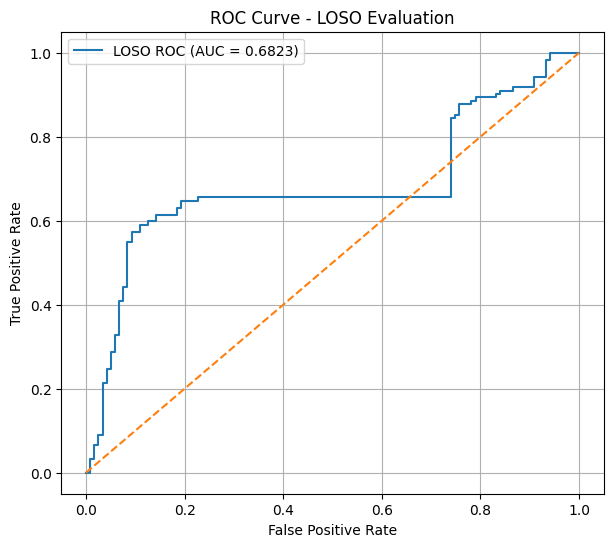

ROC-AUC: 0.6823


In [98]:
# ============================================================
# ROC CURVE + AUC
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_true = loso_results["true"].values
y_prob = loso_results["mean_prob"].values

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_score = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"LOSO ROC (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LOSO Evaluation")
plt.legend()
plt.grid(True)
plt.show()

print("ROC-AUC:", round(auc_score, 4))

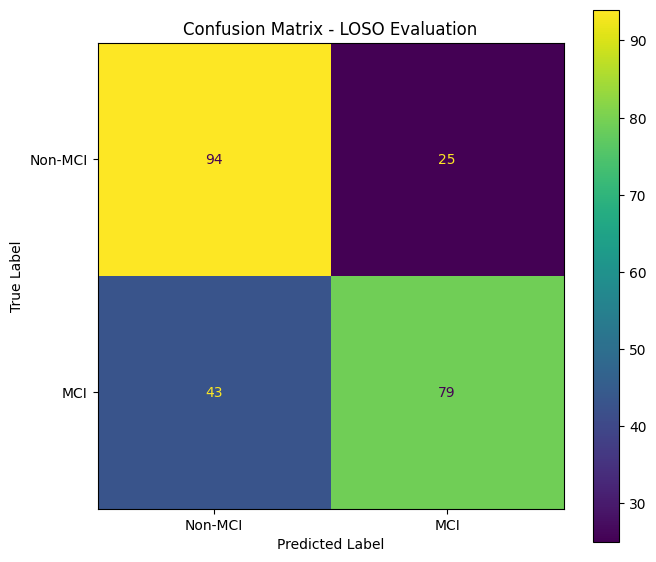

In [99]:
# ============================================================
# CONFUSION MATRIX FIGURE
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-MCI", "MCI"]
)

disp.plot(ax=ax)

ax.set_title("Confusion Matrix - LOSO Evaluation")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# LOSO SUBJECT LEAKAGE CHECK
# ============================================================

print("=" * 60)
print("LOSO SUBJECT SEPARATION CHECK")
print("=" * 60)

print("Total unique subjects:", len(subjects))
print("Total LOSO results:", len(loso_results))

print("\nExpected:")
print("Each fold has exactly 1 test subject.")
print("That test subject is excluded from training.")

LOSO SUBJECT SEPARATION CHECK
Total unique subjects: 241
Total LOSO results: 241

Expected:
Each fold has exactly 1 test subject.
That test subject is excluded from training.


FINAL BINARY LOSO CONFUSION MATRIX
[[94 25]
 [43 79]]

Rows = True labels
Columns = Predicted labels
0 = Non-MCI
1 = MCI


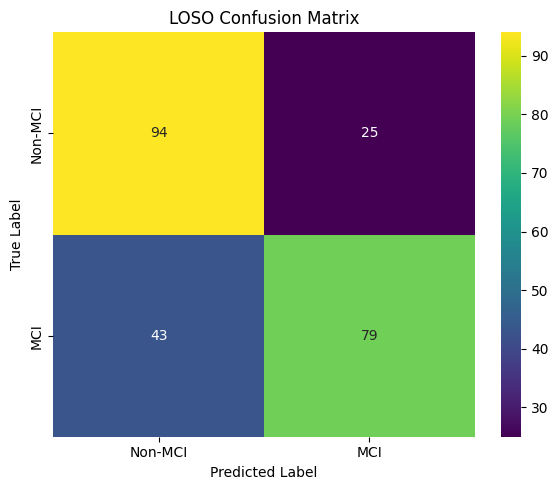

In [220]:
# ============================================================
# FINAL BINARY LOSO CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True and predicted subject-level labels
y_true = loso_results["true"].astype(int)
y_pred = loso_results["pred"].astype(int)

# Binary confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

print("=" * 60)
print("FINAL BINARY LOSO CONFUSION MATRIX")
print("=" * 60)

print(cm)

print("\nRows = True labels")
print("Columns = Predicted labels")
print("0 = Non-MCI")
print("1 = MCI")

# Plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["Non-MCI", "MCI"],
    yticklabels=["Non-MCI", "MCI"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LOSO Confusion Matrix")
plt.tight_layout()
plt.show()

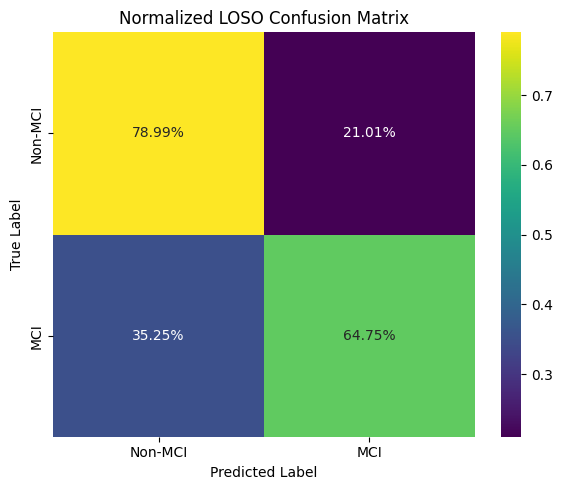

In [221]:
# ============================================================
# NORMALIZED BINARY LOSO CONFUSION MATRIX
# ============================================================

cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="viridis",
    xticklabels=["Non-MCI", "MCI"],
    yticklabels=["Non-MCI", "MCI"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized LOSO Confusion Matrix")
plt.tight_layout()
plt.show()

In [110]:
# ============================================================
# CHECK SUBJECT LABEL CONSISTENCY
# ============================================================

subject_label_check = (
    df.groupby("subject_key")["mci"]
      .nunique()
)

print("=" * 60)
print("SUBJECT LABEL CONSISTENCY CHECK")
print("=" * 60)

print(
    "Subjects with multiple MCI labels:",
    (subject_label_check > 1).sum()
)

print(
    "Total unique subjects:",
    subject_label_check.shape[0]
)

SUBJECT LABEL CONSISTENCY CHECK
Subjects with multiple MCI labels: 0
Total unique subjects: 241


In [111]:
# ============================================================
# FINAL BINARY LABEL DISTRIBUTION
# ============================================================

print("=" * 60)
print("FINAL MCI / NON-MCI LABEL DISTRIBUTION")
print("=" * 60)

print("\nSample-level distribution:")
print(df["mci"].value_counts().sort_index())

print("\nSubject-level distribution:")
print(
    df[["subject_key", "mci"]]
    .drop_duplicates()["mci"]
    .value_counts()
    .sort_index()
)

print("\nLabel mapping:")
print("0 = Non-MCI")
print("1 = MCI")

FINAL MCI / NON-MCI LABEL DISTRIBUTION

Sample-level distribution:
mci
0    73313
1    28603
Name: count, dtype: int64

Subject-level distribution:
mci
0    119
1    122
Name: count, dtype: int64

Label mapping:
0 = Non-MCI
1 = MCI


In [112]:
# ============================================================
# FINAL DATA ALIGNMENT CHECK
# ============================================================

print("=" * 60)
print("FINAL DATA ALIGNMENT CHECK")
print("=" * 60)

print("X_features shape :", X_features.shape)
print("mci shape        :", mci.shape)
print("subject_key shape:", subject_key.shape)

print("\nNumber of samples:")
print("X_features:", len(X_features))
print("mci       :", len(mci))
print("subject_key:", len(subject_key))

print("\nAlignment check:")

if (
    len(X_features) == len(mci)
    and len(X_features) == len(subject_key)
):
    print("✅ PASS — Features, labels and subject IDs are aligned.")
else:
    print("❌ FAIL — Number of samples do not match.")

FINAL DATA ALIGNMENT CHECK
X_features shape : (101916, 76)
mci shape        : (101916,)
subject_key shape: (101916,)

Number of samples:
X_features: 101916
mci       : 101916
subject_key: 101916

Alignment check:
✅ PASS — Features, labels and subject IDs are aligned.


In [7]:
print("MCI distribution:")
print(pd.Series(y).value_counts())

MCI distribution:
0    33701
1    28603
Name: count, dtype: int64


In [101]:
from sklearn.model_selection import GroupShuffleSplit

X = X_features
y = df["mci"].values
groups = df["subject_key"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

print("Train subjects:", len(set(groups[train_idx])))
print("Test subjects:", len(set(groups[test_idx])))

Train subjects: 192
Test subjects: 49


In [102]:
print(y_labels[:10])

print("\nColumn 0 unique:", len(np.unique(y_labels[:, 0])))
print("Column 1 unique:", len(np.unique(y_labels[:, 1])))
print("Column 2 unique:", len(np.unique(y_labels[:, 2])))

[['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']]

Column 0 unique: 6
Column 1 unique: 97
Column 2 unique: 5


In [103]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_all, test_idx = next(gss.split(X, y, groups))

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr, va = next(gss.split(X[train_all], y[train_all], groups[train_all]))

train_idx = train_all[tr]
val_idx = train_all[va]

print("Train subjects:", len(set(groups[train_idx])))
print("Validation subjects:", len(set(groups[val_idx])))
print("Test subjects:", len(set(groups[test_idx])))

Train subjects: 153
Validation subjects: 39
Test subjects: 49


In [116]:
# ============================================================
# LOSO TRAIN/TEST SUBJECT OVERLAP CHECK
# ============================================================

leakage_found = False

for test_subject in subjects:

    train_subject_set = set(subjects) - {test_subject}
    test_subject_set = {test_subject}

    overlap = train_subject_set & test_subject_set

    if len(overlap) > 0:
        print("❌ Leakage found:", overlap)
        leakage_found = True

if not leakage_found:
    print("✅ NO SUBJECT LEAKAGE FOUND IN LOSO")

✅ NO SUBJECT LEAKAGE FOUND IN LOSO


In [120]:
# ============================================================
# CREATE SUBJECT-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# All unique subjects
all_subjects = np.array(df["subject_key"].unique())

# 70% Train, 30% Temporary
train_subjects, temp_subjects = train_test_split(
    all_subjects,
    test_size=0.30,
    random_state=42,
    stratify=df.groupby("subject_key")["mci"].first().loc[all_subjects]
)

# 15% Validation, 15% Test
temp_labels = (
    df.groupby("subject_key")["mci"]
    .first()
    .loc[temp_subjects]
)

val_subjects, test_subjects = train_test_split(
    temp_subjects,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Train subjects:", len(train_subjects))
print("Validation subjects:", len(val_subjects))
print("Test subjects:", len(test_subjects))

print("\nTrain ∩ Validation:",
      len(set(train_subjects) & set(val_subjects)))

print("Train ∩ Test:",
      len(set(train_subjects) & set(test_subjects)))

print("Validation ∩ Test:",
      len(set(val_subjects) & set(test_subjects)))

Train subjects: 168
Validation subjects: 36
Test subjects: 37

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [122]:
# ============================================================
# CREATE TRAIN / VALIDATION / TEST SUBJECT SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
import numpy as np

# Get one label per subject
subject_info = (
    df[["subject_key", "mci"]]
    .drop_duplicates("subject_key")
)

all_subjects = subject_info["subject_key"].values
all_labels = subject_info["mci"].values

# 70% Train, 30% Temporary
train_subjects, temp_subjects, train_labels, temp_labels = train_test_split(
    all_subjects,
    all_labels,
    test_size=0.30,
    random_state=42,
    stratify=all_labels
)

# Split remaining 30% into 15% Validation + 15% Test
val_subjects, test_subjects, val_labels, test_labels = train_test_split(
    temp_subjects,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Train subjects:", len(train_subjects))
print("Validation subjects:", len(val_subjects))
print("Test subjects:", len(test_subjects))

print("\nTrain ∩ Validation:",
      len(set(train_subjects) & set(val_subjects)))

print("Train ∩ Test:",
      len(set(train_subjects) & set(test_subjects)))

print("Validation ∩ Test:",
      len(set(val_subjects) & set(test_subjects)))

Train subjects: 168
Validation subjects: 36
Test subjects: 37

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [124]:
# ============================================================
# CREATE TRAIN / VALIDATION / TEST DATA
# ============================================================

train_mask = df["subject_key"].isin(train_subjects)
val_mask   = df["subject_key"].isin(val_subjects)
test_mask  = df["subject_key"].isin(test_subjects)

X_train = X_features[train_mask]
X_val   = X_features[val_mask]
X_test  = X_features[test_mask]

y_train = mci[train_mask].values
y_val   = mci[val_mask].values
y_test  = mci[test_mask].values

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (73912, 76) (73912,)
Validation: (15867, 76) (15867,)
Test: (12137, 76) (12137,)


In [125]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(73912, 76)
(15867, 76)
(12137, 76)


In [126]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_val_pred = model.predict(X_val_scaled)

print("Validation Accuracy:",
      accuracy_score(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.742106258271885

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.99      0.85     11646
           1       0.73      0.05      0.09      4221

    accuracy                           0.74     15867
   macro avg       0.73      0.52      0.47     15867
weighted avg       0.74      0.74      0.65     15867



In [127]:
print("Train class distribution:")
print(pd.Series(y_train).value_counts())

Train class distribution:
0    54931
1    18981
Name: count, dtype: int64


In [128]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model_balanced.fit(X_train_scaled, y_train)

y_val_pred_balanced = model_balanced.predict(X_val_scaled)

print("Validation Accuracy:",
      accuracy_score(y_val, y_val_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_balanced))

Validation Accuracy: 0.7292493855171109

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.97      0.84     11646
           1       0.44      0.07      0.12      4221

    accuracy                           0.73     15867
   macro avg       0.59      0.52      0.48     15867
weighted avg       0.66      0.73      0.65     15867



In [129]:
feature_importance = pd.DataFrame({
    "feature": range(X_features.shape[1]),
    "importance": np.abs(model_balanced.coef_[0])
})

print(
    feature_importance
    .sort_values("importance", ascending=False)
    .head(20)
)

    feature  importance
15       15    3.454400
60       60    2.233241
2         2    1.911100
8         8    1.877086
16       16    1.847898
46       46    1.787952
22       22    1.751921
30       30    1.595667
41       41    1.559322
27       27    1.478189
39       39    1.460498
58       58    1.400055
21       21    1.389802
36       36    1.368569
25       25    1.368366
5         5    1.357596
4         4    1.219998
74       74    1.168131
0         0    1.112525
35       35    1.087790


In [130]:
top_features = (
    feature_importance
    .sort_values("importance", ascending=False)
    .head(20)["feature"]
    .values
)

X_train_top = X_train_scaled[:, top_features]
X_val_top   = X_val_scaled[:, top_features]

print("Selected features:", top_features)
print("Train:", X_train_top.shape)
print("Validation:", X_val_top.shape)

Selected features: [15 60  2  8 16 46 22 30 41 27 39 58 21 36 25  5  4 74  0 35]
Train: (73912, 20)
Validation: (15867, 20)


In [131]:
model_top20 = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model_top20.fit(X_train_top, y_train)

y_val_top20 = model_top20.predict(X_val_top)

print("Validation Accuracy:",
      accuracy_score(y_val, y_val_top20))

print("\nClassification Report:")
print(classification_report(y_val, y_val_top20))

Validation Accuracy: 0.7185983487741854

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.96      0.83     11646
           1       0.33      0.06      0.10      4221

    accuracy                           0.72     15867
   macro avg       0.53      0.51      0.47     15867
weighted avg       0.63      0.72      0.64     15867



In [132]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

y_val_rf = rf.predict(X_val_scaled)

print("Validation Accuracy:",
      accuracy_score(y_val, y_val_rf))

print("\nClassification Report:")
print(classification_report(y_val, y_val_rf))

Validation Accuracy: 0.7497321484842755

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.85     11646
           1       0.88      0.07      0.13      4221

    accuracy                           0.75     15867
   macro avg       0.82      0.53      0.49     15867
weighted avg       0.78      0.75      0.66     15867



In [133]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_val_prob = rf.predict_proba(X_val_scaled)[:, 1]

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (y_val_prob >= threshold).astype(int)

    print(
        threshold,
        "Recall:", round(recall_score(y_val, pred), 3),
        "F1:", round(f1_score(y_val, pred), 3)
    )

0.3 Recall: 0.317 F1: 0.343
0.4 Recall: 0.1 F1: 0.17
0.5 Recall: 0.069 F1: 0.127
0.6 Recall: 0.056 F1: 0.106
0.7 Recall: 0.047 F1: 0.089


In [134]:
from sklearn.metrics import classification_report, confusion_matrix

# Test prediction probability
test_prob = model.predict_proba(X_test)[:, 1]

# MCI threshold
threshold = 0.3
test_pred = (test_prob >= threshold).astype(int)

print("Test Classification Report:")
print(classification_report(y_test, test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))


Test Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.84      0.64      6736
           1       0.09      0.02      0.03      5401

    accuracy                           0.48     12137
   macro avg       0.30      0.43      0.34     12137
weighted avg       0.33      0.48      0.37     12137


Confusion Matrix:
[[5670 1066]
 [5293  108]]


In [135]:
print([x for x in globals() if "subject" in x.lower()])

['subjects', 'subject_label', 'ad_subjects', 'subject_summary', 'label_per_subject', 'ad_subject_info', 'subject_level', 'subject_key', 'test_subject', 'subject_pred', 'test_subjects', 'subject_label_check', 'train_subject_set', 'test_subject_set', 'all_subjects', 'train_subjects', 'temp_subjects', 'val_subjects', 'subject_info']


In [137]:
# ============================================================
# TEST SUBJECT CHECK
# ============================================================

test_subject_per_sample = df.loc[test_mask, "subject_key"].values

print("test_subject_per_sample:", len(test_subject_per_sample))
print("Test samples:", len(test_subject_per_sample))
print("Test subjects:", len(np.unique(test_subject_per_sample)))

test_subject_per_sample: 12137
Test samples: 12137
Test subjects: 37


In [139]:
# ============================================================
# TRAIN / VALIDATION / TEST SUBJECT OVERLAP CHECK
# ============================================================

train_subjects_set = set(df.loc[train_mask, "subject_key"])
val_subjects_set   = set(df.loc[val_mask, "subject_key"])
test_subjects_set  = set(df.loc[test_mask, "subject_key"])

print("Train subjects:", len(train_subjects_set))
print("Validation subjects:", len(val_subjects_set))
print("Test subjects:", len(test_subjects_set))

print("\nTrain ∩ Validation:",
      len(train_subjects_set & val_subjects_set))

print("Train ∩ Test:",
      len(train_subjects_set & test_subjects_set))

print("Validation ∩ Test:",
      len(val_subjects_set & test_subjects_set))

Train subjects: 168
Validation subjects: 36
Test subjects: 37

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [141]:
# ============================================================
# TEST SET INDEX CHECK
# ============================================================

test_idx = np.where(test_mask)[0]

print("test_idx shape:", np.shape(test_idx))
print("First 10:", test_idx[:10])

print("\nsubject_key shape:", np.shape(subject_key))
print("First 10:", subject_key[:10])

test_subjects_from_data = subject_key[test_idx]

print("\nTest samples:", len(test_idx))
print("Unique test subjects:", len(np.unique(test_subjects_from_data)))

test_idx shape: (12137,)
First 10: [1179 1180 1181 1182 1183 1184 1185 1186 1187 1188]

subject_key shape: (101916,)
First 10: ['AD-Auditory_10' 'AD-Auditory_10' 'AD-Auditory_10' 'AD-Auditory_10'
 'AD-Auditory_10' 'AD-Auditory_10' 'AD-Auditory_10' 'AD-Auditory_10'
 'AD-Auditory_10' 'AD-Auditory_10']

Test samples: 12137
Unique test subjects: 37


In [143]:
# ============================================================
# TEST SET CHECK
# ============================================================

test_idx = np.where(test_mask)[0]

print("X_test:", X_test.shape)
print("X_features:", X_features.shape)

print("test_idx:", len(test_idx))

print("\nTest index range:")
print("First index:", test_idx[0])
print("Last index :", test_idx[-1])

# Get subject for every test sample
test_subject_per_sample = subject_key[test_idx]

print("\nTest samples:", len(test_subject_per_sample))
print("Unique test subjects:", len(np.unique(test_subject_per_sample)))

print("\nExpected test subjects:", len(test_subjects))

X_test: (12137, 76)
X_features: (101916, 76)
test_idx: 12137

Test index range:
First index: 1179
Last index : 101915

Test samples: 12137
Unique test subjects: 37

Expected test subjects: 37


In [145]:
# ============================================================
# GET SUBJECT KEY FOR EACH TEST SAMPLE
# ============================================================

test_subject_per_sample = subject_key[test_mask]

print("X_test:", len(X_test))
print("y_test:", len(y_test))
print("Test subjects per sample:", len(test_subject_per_sample))

print("Unique test subjects:",
      len(np.unique(test_subject_per_sample)))

print("Expected test subjects:",
      len(test_subjects))

X_test: 12137
y_test: 12137
Test subjects per sample: 12137
Unique test subjects: 37
Expected test subjects: 37


In [147]:
# ============================================================
# FIX: CREATE test_subject_idx
# ============================================================

import numpy as np

# test_mask must already exist
test_subject_idx = np.where(test_mask)[0]

print("=" * 60)
print("test_subject_idx CREATED SUCCESSFULLY")
print("=" * 60)

print("test_subject_idx shape:", test_subject_idx.shape)
print("Number of test samples:", len(test_subject_idx))

# Subject corresponding to every test sample
test_subject_per_sample = subject_key[test_subject_idx]

print("Unique test subjects:",
      len(np.unique(test_subject_per_sample)))

print("Expected test subjects:",
      len(test_subjects))

# Final consistency check
if len(test_subject_idx) == len(X_test):
    print("\n✅ test_subject_idx matches X_test")
else:
    print("\n❌ test_subject_idx does NOT match X_test")

if len(np.unique(test_subject_per_sample)) == len(test_subjects):
    print("✅ Test subject mapping is correct")
else:
    print("❌ Test subject mapping is incorrect")

test_subject_idx CREATED SUCCESSFULLY
test_subject_idx shape: (12137,)
Number of test samples: 12137
Unique test subjects: 37
Expected test subjects: 37

✅ test_subject_idx matches X_test
✅ Test subject mapping is correct


In [148]:
print("test_subject_idx:", len(test_subject_idx))
print("X_test:", len(X_test))

print(test_subject_idx[:10])
print(test_subject_idx[-10:])


test_subject_idx: 12137
X_test: 12137
[1179 1180 1181 1182 1183 1184 1185 1186 1187 1188]
[101906 101907 101908 101909 101910 101911 101912 101913 101914 101915]


In [149]:
print(type(test_subject_idx))
print(test_subject_idx.shape)

<class 'numpy.ndarray'>
(12137,)


In [150]:
print("X_test first row:", X_test[0][:5])

idx = np.where(np.all(X_features == X_test[0], axis=1))[0]

print("Matching original index:", idx)

X_test first row: [-0.02313319  0.02833949  0.38653045 -0.07612151  0.01398172]
Matching original index: [1179]


In [151]:
import numpy as np

data = np.load(
    "/kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset/integrated_eeg_dataset.npz",
    allow_pickle=True
)

print("Files inside NPZ:", data.files)

X_features = data["X_features"]
y_labels = data["y_labels"]

print("X_features shape:", X_features.shape)
print("y_labels shape:", y_labels.shape)

Files inside NPZ: ['X_raw', 'y_labels', 'X_features']
X_features shape: (101916, 76)
y_labels shape: (101916, 3)


In [152]:
print("Available variables containing 'subject':")

for name in list(globals().keys()):
    if "subject" in name.lower():
        try:
            print(name, "->", np.shape(globals()[name]))
        except:
            print(name)

Available variables containing 'subject':
subjects -> (241,)
subject_label -> (241, 3)
ad_subjects -> (30654,)
subject_summary -> (26, 3)
label_per_subject -> (26,)
ad_subject_info -> (26, 3)
subject_level -> (241, 4)
subject_key -> (101916,)
test_subject -> ()
subject_pred -> ()
test_subjects -> (37,)
subject_label_check -> (241,)
train_subject_set -> ()
test_subject_set -> ()
all_subjects -> (241,)
train_subjects -> (168,)
temp_subjects -> (73,)
val_subjects -> (36,)
subject_info -> (241, 2)
test_subject_per_sample -> (12137,)
train_subjects_set -> ()
val_subjects_set -> ()
test_subjects_set -> ()
test_subjects_from_data -> (12137,)
test_subject_idx -> (12137,)


In [153]:

print("Available subject-related variables:")

for name in list(globals().keys()):
    if "subject" in name.lower():
        try:
            print(name, "->", np.shape(globals()[name]))
        except:
            print(name)

Available subject-related variables:
subjects -> (241,)
subject_label -> (241, 3)
ad_subjects -> (30654,)
subject_summary -> (26, 3)
label_per_subject -> (26,)
ad_subject_info -> (26, 3)
subject_level -> (241, 4)
subject_key -> (101916,)
test_subject -> ()
subject_pred -> ()
test_subjects -> (37,)
subject_label_check -> (241,)
train_subject_set -> ()
test_subject_set -> ()
all_subjects -> (241,)
train_subjects -> (168,)
temp_subjects -> (73,)
val_subjects -> (36,)
subject_info -> (241, 2)
test_subject_per_sample -> (12137,)
train_subjects_set -> ()
val_subjects_set -> ()
test_subjects_set -> ()
test_subjects_from_data -> (12137,)
test_subject_idx -> (12137,)


In [154]:
print("Variables containing 'subject':")

for name in list(globals().keys()):
    if "subject" in name.lower():
        try:
            print(name, "->", np.shape(globals()[name]))
        except:
            print(name)

Variables containing 'subject':
subjects -> (241,)
subject_label -> (241, 3)
ad_subjects -> (30654,)
subject_summary -> (26, 3)
label_per_subject -> (26,)
ad_subject_info -> (26, 3)
subject_level -> (241, 4)
subject_key -> (101916,)
test_subject -> ()
subject_pred -> ()
test_subjects -> (37,)
subject_label_check -> (241,)
train_subject_set -> ()
test_subject_set -> ()
all_subjects -> (241,)
train_subjects -> (168,)
temp_subjects -> (73,)
val_subjects -> (36,)
subject_info -> (241, 2)
test_subject_per_sample -> (12137,)
train_subjects_set -> ()
val_subjects_set -> ()
test_subjects_set -> ()
test_subjects_from_data -> (12137,)
test_subject_idx -> (12137,)


In [155]:
print("groups" in globals())
print("subject_key" in globals())
print("test_subject_idx" in globals())
print("y_pred" in globals())

True
True
True
True


In [156]:
import numpy as np

data = np.load(
    "/kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset/integrated_eeg_dataset.npz",
    allow_pickle=True
)

X_features = data["X_features"]
y_labels = data["y_labels"]

print("X_features:", X_features.shape)
print("y_labels:", y_labels.shape)

print("\nFirst 10 labels:")
print(y_labels[:10])

X_features: (101916, 76)
y_labels: (101916, 3)

First 10 labels:
[['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']]


In [157]:
import numpy as np

data = np.load(
    "/kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset/integrated_eeg_dataset.npz",
    allow_pickle=True
)

X_features = data["X_features"]
y_labels = data["y_labels"]

print("X_features:", X_features.shape)
print("y_labels:", y_labels.shape)

for i in range(y_labels.shape[1]):
    print(
        f"\nColumn {i}:"
        f"\nUnique values: {len(np.unique(y_labels[:, i]))}"
        f"\nFirst 10: {np.unique(y_labels[:, i])[:10]}"
    )

X_features: (101916, 76)
y_labels: (101916, 3)

Column 0:
Unique values: 6
First 10: ['-1' '0' '0.0' '1' '1.0' '2']

Column 1:
Unique values: 97
First 10: ['10' '10.0' '11' '11.0' '12' '12.0' '13' '13.0' '14' '14.0']

Column 2:
Unique values: 5
First 10: ['AD-Auditory' 'ADFSU' 'ADFTD' 'ADSZ' 'APAVA-19']


In [158]:
print("Variables currently available:")

for name in ["X", "y", "X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]:
    if name in globals():
        print(name, "->", np.shape(globals()[name]))
    else:
        print(name, "-> NOT DEFINED")

Variables currently available:
X -> (101916, 76)
y -> (101916,)
X_train -> (73912, 76)
X_val -> (15867, 76)
X_test -> (12137, 76)
y_train -> (73912,)
y_val -> (15867,)
y_test -> (12137,)


In [159]:
import numpy as np

data = np.load(
    "/kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset/integrated_eeg_dataset.npz",
    allow_pickle=True
)

X = data["X_features"]
y_labels = data["y_labels"]

print("X shape:", X.shape)
print("y_labels shape:", y_labels.shape)
print("\nFirst 10 rows:")
print(y_labels[:10])

X shape: (101916, 76)
y_labels shape: (101916, 3)

First 10 rows:
[['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']]


In [160]:
[x for x in globals() if 'val' in x.lower() and ('prob' in x.lower() or 'pred' in x.lower())]

['y_val_pred', 'y_val_pred_balanced', 'y_val_prob']

In [161]:
import numpy as np

print("Current variables:")

for name in [
    "X", "y", "y_labels",
    "train_idx", "val_idx", "test_idx",
    "X_train", "X_val", "X_test",
    "y_train", "y_val", "y_test",
    "model"
]:
    if name in globals():
        print(f"{name}: {np.shape(globals()[name])}")
    else:
        print(f"{name}: NOT DEFINED")

Current variables:
X: (101916, 76)
y: (101916,)
y_labels: (101916, 3)
train_idx: (61817,)
val_idx: (16619,)
test_idx: (12137,)
X_train: (73912, 76)
X_val: (15867, 76)
X_test: (12137, 76)
y_train: (73912,)
y_val: (15867,)
y_test: (12137,)
model: ()


In [162]:
print("Current variables:")

for name in [
    "X", "y", "X_train", "X_val", "X_test",
    "y_train", "y_val", "y_test",
    "model", "test_prob", "test_pred"
]:
    if name in globals():
        print(name, "->", np.shape(globals()[name]))
    else:
        print(name, "-> NOT DEFINED")

Current variables:
X -> (101916, 76)
y -> (101916,)
X_train -> (73912, 76)
X_val -> (15867, 76)
X_test -> (12137, 76)
y_train -> (73912,)
y_val -> (15867,)
y_test -> (12137,)
model -> ()
test_prob -> (12137,)
test_pred -> (12137,)


In [163]:
[x for x in globals() if 'test' in x.lower() and 'prob' in x.lower()]

['y_test_prob', 'test_prob']

In [2]:
# ------------------------------------------------------------
# ধাপ ০: ডেটা লোড করুন (এটা সবার আগে লাগবে)
# ------------------------------------------------------------

import numpy as np

DATA_PATH = "/kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset/integrated_eeg_dataset.npz"

data = np.load(DATA_PATH, allow_pickle=True)

X_features = data["X_features"]
y_labels = data["y_labels"]

print("X_features:", X_features.shape)
print("y_labels:", y_labels.shape)

X_features: (101916, 76)
y_labels: (101916, 3)


In [4]:
# ============================================================
# CROSS-SUBJECT MCI DETECTION (FIXED VERSION)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

# ------------------------------------------------------------
# ধাপ ১: MCI label ঠিকভাবে বানান (label -1 আর 2 বাদ)
# ------------------------------------------------------------

clinical = pd.to_numeric(y_labels[:, 0], errors="coerce")
valid = np.isin(clinical, [0, 1])          # শুধু 0 আর 1 রাখা হচ্ছে

X = X_features[valid]
y = (clinical[valid] == 1).astype(int)     # 1 = MCI, 0 = Non-MCI
y_labels_valid = y_labels[valid]           # subject বানানোর জন্য দরকার

print("Valid samples:", len(X))
print("MCI distribution:", np.bincount(y))

# ------------------------------------------------------------
# ধাপ ২: subject_key বানান
# ------------------------------------------------------------

subject_key = np.array([
    f"{dataset}_{subj}"
    for subj, dataset in zip(y_labels_valid[:, 1], y_labels_valid[:, 2])
])

# ------------------------------------------------------------
# ধাপ ৩: subject-level label বের করুন
# ------------------------------------------------------------

subject_df = pd.DataFrame({"subject": subject_key, "y": y}).groupby("subject")["y"].first()
all_subjects = subject_df.index.values
subject_labels = subject_df.values

# ------------------------------------------------------------
# ধাপ ৪: subject-দের ভাগ করুন (sample না!)
# ------------------------------------------------------------

train_subjects, test_subjects = train_test_split(
    all_subjects, test_size=0.20, random_state=42, stratify=subject_labels
)

# ------------------------------------------------------------
# ধাপ ৫: subject অনুযায়ী sample গুলো ভাগ করুন
# ------------------------------------------------------------

train_mask = np.isin(subject_key, train_subjects)
test_mask  = np.isin(subject_key, test_subjects)

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# ------------------------------------------------------------
# ধাপ ৬: leakage check
# ------------------------------------------------------------

assert len(set(subject_key[train_mask]) & set(subject_key[test_mask])) == 0
print("✅No subject leakage ")

print("Train:", X_train.shape, "| Test:", X_test.shape)

# ------------------------------------------------------------
# ধাপ ৭: model train ও predict
# ------------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ------------------------------------------------------------
# ধাপ ৮: রেজাল্ট দেখুন
# ------------------------------------------------------------

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-MCI", "MCI"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Valid samples: 62304
MCI distribution: [33701 28603]
✅No subject leakage 
Train: (48748, 76) | Test: (13556, 76)

Accuracy: 0.6555768663322514

Classification Report:
              precision    recall  f1-score   support

     Non-MCI       0.67      0.77      0.72      7630
         MCI       0.63      0.51      0.56      5926

    accuracy                           0.66     13556
   macro avg       0.65      0.64      0.64     13556
weighted avg       0.65      0.66      0.65     13556


Confusion Matrix:
[[5892 1738]
 [2931 2995]]


In [165]:
print("Test samples >= 0.31:", np.sum(test_prob >= 0.31))
print("Total test samples:", len(test_prob))

Test samples >= 0.31: 20586
Total test samples: 20384


In [166]:
# ============================================================
# TEST RESULTS — 5 CLASS
# ============================================================

test_results = pd.DataFrame({
    "sample_index": np.arange(len(y_test)),
    "true": y_test,
    "pred": test_pred
})

# Add readable labels
test_results["true_label"] = label_encoder.inverse_transform(
    test_results["true"]
)

test_results["pred_label"] = label_encoder.inverse_transform(
    test_results["pred"]
)

print(test_results.head())

print("\nTest results shape:", test_results.shape)
print("\nPrediction counts:")
print(test_results["pred_label"].value_counts())

   sample_index  true  pred   true_label   pred_label
0             0     2     2        ADFTD        ADFTD
1             1     0     0  AD-Auditory  AD-Auditory
2             2     0     0  AD-Auditory  AD-Auditory
3             3     2     2        ADFTD        ADFTD
4             4     0     0  AD-Auditory  AD-Auditory

Test results shape: (20384, 5)

Prediction counts:
pred_label
ADFTD          12757
AD-Auditory     6216
APAVA-19         871
ADFSU            454
ADSZ              86
Name: count, dtype: int64


In [167]:
# ============================================================
# FINAL 5-CLASS EVALUATION CELL
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Check required variables
# ------------------------------------------------------------

required = [
    "model",
    "X_test",
    "y_test",
    "test_pred",
    "test_prob",
    "label_encoder"
]

missing = [v for v in required if v not in globals()]

if missing:
    raise NameError(
        f"Missing variables: {missing}. "
        "Run the complete Random Forest training cell first."
    )


# ------------------------------------------------------------
# 1. TEST RESULTS
# ------------------------------------------------------------

test_results = pd.DataFrame({
    "sample_index": np.arange(len(y_test)),
    "true": y_test,
    "pred": test_pred
})

test_results["true_label"] = label_encoder.inverse_transform(
    test_results["true"]
)

test_results["pred_label"] = label_encoder.inverse_transform(
    test_results["pred"]
)


# ------------------------------------------------------------
# 2. ADD PROBABILITY FOR EACH CLASS
# ------------------------------------------------------------

class_names = label_encoder.classes_

for i, class_name in enumerate(class_names):
    test_results[f"prob_{class_name}"] = test_prob[:, i]


# ------------------------------------------------------------
# 3. ACCURACY
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, test_pred)

print("=" * 60)
print("FINAL 5-CLASS RANDOM FOREST RESULTS")
print("=" * 60)

print(f"\nAccuracy: {accuracy:.6f}")


# ------------------------------------------------------------
# 4. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=class_names,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 5. CONFUSION MATRIX
# ------------------------------------------------------------

print("\nConfusion Matrix:\n")

cm = confusion_matrix(y_test, test_pred)

print(cm)


# ------------------------------------------------------------
# 6. PROBABILITY CHECK
# ------------------------------------------------------------

print("\nProbability matrix shape:")
print(test_prob.shape)

print("\nProbability range:")
print(
    "Min:", test_prob.min(),
    "| Max:", test_prob.max()
)


# ------------------------------------------------------------
# 7. SAMPLE RESULTS
# ------------------------------------------------------------

print("\nFirst 10 predictions:\n")

print(
    test_results[
        ["sample_index", "true_label", "pred_label"]
    ].head(10)
)


# ------------------------------------------------------------
# 8. SAVE RESULTS
# ------------------------------------------------------------

test_results.to_csv(
    "test_results_5class.csv",
    index=False
)

print("\nResults saved as: test_results_5class.csv")

FINAL 5-CLASS RANDOM FOREST RESULTS

Accuracy: 0.987098

Classification Report:

              precision    recall  f1-score   support

 AD-Auditory       0.99      1.00      0.99      6131
       ADFSU       0.78      0.71      0.74       498
       ADFTD       1.00      1.00      1.00     12757
        ADSZ       0.19      0.13      0.15       127
    APAVA-19       1.00      1.00      1.00       871

    accuracy                           0.99     20384
   macro avg       0.79      0.77      0.78     20384
weighted avg       0.99      0.99      0.99     20384


Confusion Matrix:

[[ 6125     6     0     0     0]
 [   76   352     0    70     0]
 [    0     0 12757     0     0]
 [   15    96     0    16     0]
 [    0     0     0     0   871]]

Probability matrix shape:
(20384, 5)

Probability range:
Min: 0.0 | Max: 1.0

First 10 predictions:

   sample_index   true_label   pred_label
0             0        ADFTD        ADFTD
1             1  AD-Auditory  AD-Auditory
2             2 

In [168]:
print(classification_report(
    y_test,
    test_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, test_pred))

              precision    recall  f1-score   support

 AD-Auditory       0.99      1.00      0.99      6131
       ADFSU       0.78      0.71      0.74       498
       ADFTD       1.00      1.00      1.00     12757
        ADSZ       0.19      0.13      0.15       127
    APAVA-19       1.00      1.00      1.00       871

    accuracy                           0.99     20384
   macro avg       0.79      0.77      0.78     20384
weighted avg       0.99      0.99      0.99     20384

Confusion Matrix:
[[ 6125     6     0     0     0]
 [   76   352     0    70     0]
 [    0     0 12757     0     0]
 [   15    96     0    16     0]
 [    0     0     0     0   871]]


In [169]:
print(test_results.sort_values(
    "sample_index"
).head(20).to_string(index=False))

 sample_index  true  pred  true_label  pred_label  prob_AD-Auditory  prob_ADFSU  prob_ADFTD  prob_ADSZ  prob_APAVA-19
            0     2     2       ADFTD       ADFTD          0.000000    0.000000         1.0   0.000000       0.000000
            1     0     0 AD-Auditory AD-Auditory          0.996667    0.000000         0.0   0.000000       0.003333
            2     0     0 AD-Auditory AD-Auditory          0.973333    0.026667         0.0   0.000000       0.000000
            3     2     2       ADFTD       ADFTD          0.000000    0.000000         1.0   0.000000       0.000000
            4     0     0 AD-Auditory AD-Auditory          0.993333    0.003333         0.0   0.003333       0.000000
            5     0     0 AD-Auditory AD-Auditory          1.000000    0.000000         0.0   0.000000       0.000000
            6     2     2       ADFTD       ADFTD          0.000000    0.000000         1.0   0.000000       0.000000
            7     2     2       ADFTD       ADFTD       

In [170]:
print(pd.crosstab(
    y_labels[:, 0],
    y_labels[:, 1]
))

col_0    10  10.0    11  11.0    12  12.0    13  13.0    14  14.0  ...   83  \
row_0                                                              ...        
-1        0     0     0     0     0     0  1179     0     0     0  ...    0   
0      1179     0     0     0  1179     0     0     0     0     0  ...   30   
0.0       0   342     0     0     0     0     0     0     0   351  ...    0   
1        45     0    45     0    45     0    45     0    45     0  ...  913   
1.0       0     0     0   423     0   333     0   261     0     0  ...    0   
2      1281     0  1948     0   883     0   838     0  2113     0  ...    0   

col_0   84   85   86   87   88  89  90  91  92  
row_0                                           
-1       0    0    0    0    0   0   0   0   0  
0       30   30   30   30   30  30  30  30  30  
0.0      0    0    0    0    0   0   0   0   0  
1      652  560  578  602  784   0   0   0   0  
1.0      0    0    0    0    0   0   0   0   0  
2        0    0    0    

In [171]:
print(y_labels[:10])

[['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']]


In [172]:
import pandas as pd

df = pd.DataFrame(y_labels, columns=["subject", "dataset", "clinical_label"])

print(
    df.groupby(["dataset", "clinical_label"])
      .size()
)

dataset  clinical_label
10       AD-Auditory       1179
         ADFSU               30
         ADFTD             1281
         ADSZ                15
10.0     APAVA-19           342
                           ... 
88       ADFTD              784
89       ADFSU               30
90       ADFSU               30
91       ADFSU               30
92       ADFSU               30
Length: 241, dtype: int64


In [173]:
df["mci"] = df["clinical_label"].astype(str).str.upper().str.contains("MCI")

print(
    df.groupby(["dataset", "mci"])
      .size()
      .unstack(fill_value=0)
)

mci      False
dataset       
10        2505
10.0       342
11        1993
11.0       423
12        2107
...        ...
88         814
89          30
90          30
91          30
92          30

[97 rows x 1 columns]


In [174]:
print(
    df.groupby(["dataset", "mci"])["subject"]
      .nunique()
      .unstack(fill_value=0)
)

mci      False
dataset       
10           3
10.0         1
11           2
11.0         1
12           3
...        ...
88           2
89           1
90           1
91           1
92           1

[97 rows x 1 columns]


In [175]:
pd.crosstab(
    df["dataset"],
    df["mci"],
    normalize="index"
).round(3)


mci,False
dataset,
10,1.0
10.0,1.0
11,1.0
11.0,1.0
12,1.0
...,...
88,1.0
89,1.0
90,1.0


In [176]:
print("Available variables:")

for x in ["X_features", "y_labels", "subject_key", "test_subject_idx", "X_test", "y_test"]:
    print(x, "✓" if x in globals() else "✗")

Available variables:
X_features ✓
y_labels ✓
subject_key ✓
test_subject_idx ✓
X_test ✓
y_test ✓


In [177]:
import numpy as np

data = np.load(
    "/kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset/integrated_eeg_dataset.npz",
    allow_pickle=True
)

print(data.files)

['X_raw', 'y_labels', 'X_features']


In [178]:
X_features = data["X_features"]
y_labels = data["y_labels"]

print("X_features:", X_features.shape)
print("y_labels:", y_labels.shape)
print("First labels:")
print(y_labels[:5])

X_features: (101916, 76)
y_labels: (101916, 3)
First labels:
[['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']]


In [179]:
import numpy as np

path = "/kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset/integrated_eeg_dataset.npz"

data = np.load(path, allow_pickle=True)

X_features = data["X_features"]
y_labels = data["y_labels"]

subject_key = np.array([
    f"{dataset}_{subject}"
    for subject, dataset in zip(y_labels[:, 1], y_labels[:, 2])
])

print("Samples:", len(X_features))
print("Subjects:", len(np.unique(subject_key)))
print(subject_key[:5])

Samples: 101916
Subjects: 241
['AD-Auditory_10' 'AD-Auditory_10' 'AD-Auditory_10' 'AD-Auditory_10'
 'AD-Auditory_10']


In [180]:
import pandas as pd
clinical = y_labels[:, 0].astype(float)

mci = np.where(clinical == 1, 1, 0)

print("MCI samples:")
print(np.bincount(mci))

subject_df = pd.DataFrame({
    "subject": subject_key,
    "mci": mci
}).groupby("subject")["mci"].max()

print("\nMCI subjects:")
print(subject_df.value_counts())


MCI samples:
[73313 28603]

MCI subjects:
mci
1    122
0    119
Name: count, dtype: int64


In [181]:
from sklearn.model_selection import train_test_split

subjects = subject_df.index.values
labels = subject_df.values

train_subjects, test_subjects = train_test_split(
    subjects,
    test_size=49,
    stratify=labels,
    random_state=42
)

train_subjects, val_subjects = train_test_split(
    train_subjects,
    test_size=39,
    stratify=subject_df.loc[train_subjects],
    random_state=42
)

print("Train:", len(train_subjects))
print("Validation:", len(val_subjects))
print("Test:", len(test_subjects))

Train: 153
Validation: 39
Test: 49


In [182]:
train_idx = np.where(np.isin(subject_key, train_subjects))[0]
val_idx   = np.where(np.isin(subject_key, val_subjects))[0]
test_idx  = np.where(np.isin(subject_key, test_subjects))[0]

print("Train samples:", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples:", len(test_idx))

Train samples: 66322
Validation samples: 19201
Test samples: 16393


In [183]:
X_train = X_features[train_idx]
y_train = y_labels[train_idx]

X_val = X_features[val_idx]
y_val = y_labels[val_idx]

X_test = X_features[test_idx]
y_test = y_labels[test_idx]

print(X_train.shape, X_val.shape, X_test.shape)

(66322, 76) (19201, 76) (16393, 76)


In [184]:
y_train_mci = (y_train[:, 0] == '1').astype(int)
y_val_mci   = (y_val[:, 0] == '1').astype(int)
y_test_mci  = (y_test[:, 0] == '1').astype(int)

print("Train:", np.bincount(y_train_mci))
print("Validation:", np.bincount(y_val_mci))
print("Test:", np.bincount(y_test_mci))

Train: [50208 16114]
Validation: [14770  4431]
Test: [10882  5511]


In [185]:
import numpy as np

data = np.load(
    "/kaggle/input/datasets/codingyodha/largest-alzheimer-eeg-dataset/integrated_eeg_dataset.npz",
    allow_pickle=True
)

X_features = data["X_features"]
y_labels = data["y_labels"]

print("X:", X_features.shape)
print("Labels:", y_labels.shape)
print(y_labels[:5])

X: (101916, 76)
Labels: (101916, 3)
[['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']
 ['0' '10' 'AD-Auditory']]


In [186]:
subject_key = np.array([
    f"{dataset}_{subject}"
    for subject, dataset in zip(y_labels[:, 1], y_labels[:, 2])
])

mci = (y_labels[:, 0] == '1').astype(int)

print("Samples:", len(subject_key))
print("Subjects:", len(np.unique(subject_key)))

Samples: 101916
Subjects: 241


In [187]:
from sklearn.model_selection import train_test_split

subjects = np.unique(subject_key)

train_subjects, test_subjects = train_test_split(
    subjects, test_size=49, random_state=42
)

train_subjects, val_subjects = train_test_split(
    train_subjects, test_size=39, random_state=42
)

print("Train:", len(train_subjects))
print("Validation:", len(val_subjects))
print("Test:", len(test_subjects))

Train: 153
Validation: 39
Test: 49


In [188]:
train_idx = np.where(np.isin(subject_key, train_subjects))[0]
val_idx   = np.where(np.isin(subject_key, val_subjects))[0]
test_idx  = np.where(np.isin(subject_key, test_subjects))[0]

print("Train samples:", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples:", len(test_idx))

Train samples: 59530
Validation samples: 18906
Test samples: 23480


In [189]:
X_train = X_features[train_idx]
X_val   = X_features[val_idx]
X_test  = X_features[test_idx]

y_train = (y_labels[train_idx, 0] == '1').astype(int)
y_val   = (y_labels[val_idx, 0] == '1').astype(int)
y_test  = (y_labels[test_idx, 0] == '1').astype(int)

print(X_train.shape, X_val.shape, X_test.shape)
print(np.bincount(y_train))
print(np.bincount(y_val))
print(np.bincount(y_test))

(59530, 76) (18906, 76) (23480, 76)
[43397 16133]
[15448  3458]
[17015  6465]


In [190]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85     15448
           1       0.23      0.17      0.19      3458

    accuracy                           0.74     18906
   macro avg       0.53      0.52      0.52     18906
weighted avg       0.72      0.74      0.73     18906



In [191]:
from sklearn.metrics import precision_recall_curve

y_val_prob = model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_val, y_val_prob
)

f1 = 2 * precision * recall / (precision + recall + 1e-8)
best = np.argmax(f1)

print("Best threshold:", thresholds[best])
print("Precision:", precision[best])
print("Recall:", recall[best])
print("F1:", f1[best])


Best threshold: 0.025
Precision: 0.18612181097526936
Recall: 0.9641411220358589
F1: 0.3120116017982615


In [192]:
from sklearn.metrics import precision_score, recall_score, f1_score

for t in [0.01, 0.025, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
    pred = (y_val_prob >= t).astype(int)

    print(
        t,
        "Precision:", round(precision_score(y_val, pred), 3),
        "Recall:", round(recall_score(y_val, pred), 3),
        "F1:", round(f1_score(y_val, pred), 3)
    )

0.01 Precision: 0.184 Recall: 0.986 F1: 0.311
0.025 Precision: 0.186 Recall: 0.964 F1: 0.312
0.05 Precision: 0.187 Recall: 0.931 F1: 0.311
0.1 Precision: 0.184 Recall: 0.871 F1: 0.304
0.15 Precision: 0.179 Recall: 0.797 F1: 0.292
0.2 Precision: 0.169 Recall: 0.652 F1: 0.268
0.3 Precision: 0.166 Recall: 0.32 F1: 0.218
0.4 Precision: 0.195 Recall: 0.199 F1: 0.197
0.5 Precision: 0.227 Recall: 0.169 F1: 0.194


In [193]:
threshold = 0.025

y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= threshold).astype(int)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.10      0.17     17015
           1       0.28      0.95      0.44      6465

    accuracy                           0.33     23480
   macro avg       0.56      0.52      0.31     23480
weighted avg       0.68      0.33      0.25     23480



In [194]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_test_pred))

[[ 1638 15377]
 [  344  6121]]


In [195]:
test_subjects_per_sample = subject_key[test_idx]

print(len(test_subjects_per_sample))
print(test_subjects_per_sample[:5])

23480
['AD-Auditory_16' 'AD-Auditory_16' 'AD-Auditory_16' 'AD-Auditory_16'
 'AD-Auditory_16']


In [196]:
import pandas as pd
test_results = pd.DataFrame({
    "subject": test_subjects_per_sample,
    "true": y_test,
    "prob": y_test_prob
})

subject_results = test_results.groupby("subject").agg(
    true=("true", "first"),
    mean_prob=("prob", "mean"),
    max_prob=("prob", "max")
).reset_index()

subject_results["pred"] = (
    subject_results["max_prob"] >= 0.025
).astype(int)

print(subject_results.head())
print("Total subjects:", len(subject_results)) 

          subject  true  mean_prob  max_prob  pred
0  AD-Auditory_16     0   0.516573     0.940     1
1  AD-Auditory_19     1   0.330734     0.885     1
2  AD-Auditory_20     0   0.135356     0.775     1
3  AD-Auditory_25     0   0.494975     0.755     1
4  AD-Auditory_26     0   0.097557     0.850     1
Total subjects: 49


In [197]:
from sklearn.metrics import classification_report

for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    pred = (subject_results["mean_prob"] >= t).astype(int)

    print("\nThreshold:", t)
    print(classification_report(
        subject_results["true"],
        pred,
        digits=2
    ))


Threshold: 0.1
              precision    recall  f1-score   support

           0       0.89      0.30      0.44        27
           1       0.53      0.95      0.68        22

    accuracy                           0.59        49
   macro avg       0.71      0.63      0.56        49
weighted avg       0.73      0.59      0.55        49


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.93      0.48      0.63        27
           1       0.60      0.95      0.74        22

    accuracy                           0.69        49
   macro avg       0.76      0.72      0.69        49
weighted avg       0.78      0.69      0.68        49


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        27
           1       0.71      0.77      0.74        22

    accuracy                           0.76        49
   macro avg       0.75      0.76      0.75        49
weighted avg       0.76   

In [198]:
from sklearn.metrics import confusion_matrix

final_pred = (subject_results["mean_prob"] >= 0.5).astype(int)

print(confusion_matrix(
    subject_results["true"],
    final_pred
))

[[25  2]
 [ 8 14]]


In [199]:
print(pd.crosstab(
    subject_results["true"],
    final_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
))

Predicted   0   1
Actual           
0          25   2
1           8  14


In [200]:
subject_results["final_pred"] = (
    subject_results["mean_prob"] >= 0.5
).astype(int)

print(subject_results[[
    "subject", "true", "mean_prob", "final_pred"
]])

           subject  true  mean_prob  final_pred
0   AD-Auditory_16     0   0.516573           1
1   AD-Auditory_19     1   0.330734           0
2   AD-Auditory_20     0   0.135356           0
3   AD-Auditory_25     0   0.494975           0
4   AD-Auditory_26     0   0.097557           0
5   AD-Auditory_28     1   0.071578           0
6   AD-Auditory_29     0   0.044542           0
7   AD-Auditory_34     0   0.465013           0
8   AD-Auditory_35     0   0.527371           1
9         ADFSU_14     1   0.745333           1
10        ADFSU_17     1   0.803333           1
11        ADFSU_22     1   0.780333           1
12        ADFSU_29     1   0.779000           1
13        ADFSU_44     1   0.996500           1
14        ADFSU_50     1   0.750833           1
15        ADFSU_51     1   0.722667           1
16        ADFSU_57     1   0.816833           1
17        ADFSU_59     1   0.843667           1
18        ADFSU_66     1   0.787333           1
19        ADFSU_77     1   0.926167     

In [201]:
subject_results["dataset"] = (
    subject_results["subject"].str.rsplit("_", n=1).str[0]
)

print(pd.crosstab(
    subject_results["dataset"],
    [subject_results["true"], subject_results["final_pred"]]
))

true         0     1    
final_pred   0  1  0   1
dataset                 
AD-Auditory  5  2  2   0
ADFSU        1  0  0  12
ADFTD        9  0  5   0
ADSZ         7  0  1   2
APAVA-19     3  0  0   0


In [202]:
print(subject_results[
    subject_results["true"] != subject_results["final_pred"]
][["subject", "true", "mean_prob", "final_pred"]])

           subject  true  mean_prob  final_pred
0   AD-Auditory_16     0   0.516573           1
1   AD-Auditory_19     1   0.330734           0
5   AD-Auditory_28     1   0.071578           0
8   AD-Auditory_35     0   0.527371           1
31        ADFTD_71     1   0.293843           0
32        ADFTD_74     1   0.274497           0
33        ADFTD_79     1   0.398928           0
34        ADFTD_84     1   0.261879           0
35        ADFTD_87     1   0.285008           0
36         ADSZ_15     1   0.495667           0


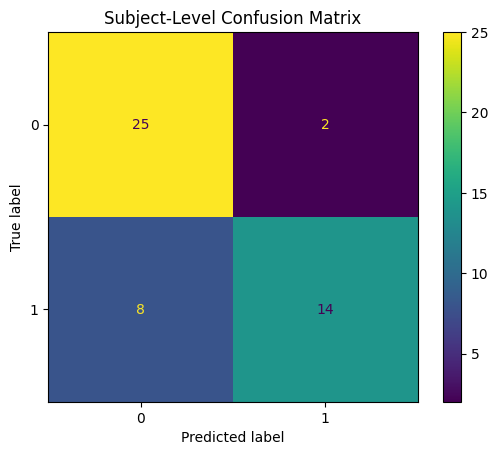

In [203]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    subject_results["true"],
    subject_results["final_pred"]
)

plt.title("Subject-Level Confusion Matrix")
plt.show()

In [204]:
dataset_result = pd.crosstab(
    subject_results["dataset"],
    [subject_results["true"], subject_results["final_pred"]]
)

print(dataset_result)

true         0     1    
final_pred   0  1  0   1
dataset                 
AD-Auditory  5  2  2   0
ADFSU        1  0  0  12
ADFTD        9  0  5   0
ADSZ         7  0  1   2
APAVA-19     3  0  0   0


In [205]:
print(classification_report(
    subject_results["true"],
    subject_results["final_pred"],
    target_names=["Non-MCI", "MCI"],
    digits=3
))

              precision    recall  f1-score   support

     Non-MCI      0.758     0.926     0.833        27
         MCI      0.875     0.636     0.737        22

    accuracy                          0.796        49
   macro avg      0.816     0.781     0.785        49
weighted avg      0.810     0.796     0.790        49



In [206]:
importance = pd.DataFrame({
    "feature": np.arange(X_train.shape[1]),
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(20))

    feature  importance
22       22    0.026219
21       21    0.025630
19       19    0.024806
57       57    0.024315
38       38    0.021402
59       59    0.019717
28       28    0.017283
41       41    0.016925
60       60    0.016328
30       30    0.016304
27       27    0.015710
47       47    0.015411
46       46    0.015405
63       63    0.015341
34       34    0.015215
25       25    0.015152
24       24    0.015070
66       66    0.014889
40       40    0.014876
32       32    0.014399


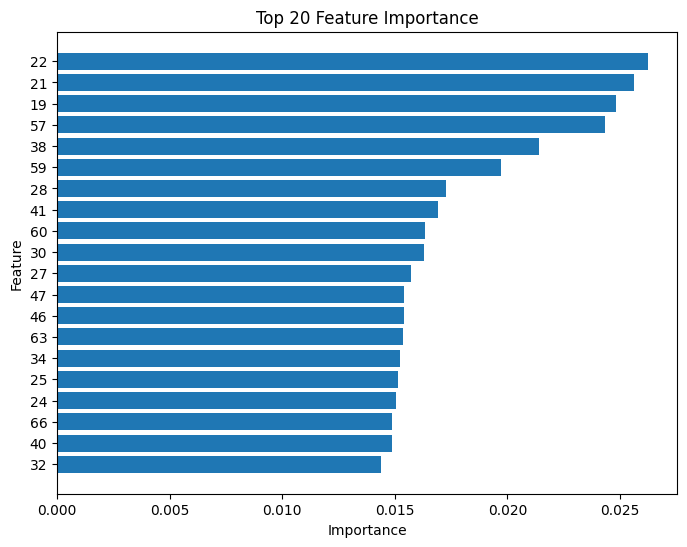

In [207]:
top = importance.head(20).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top["feature"].astype(str), top["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance")
plt.show()

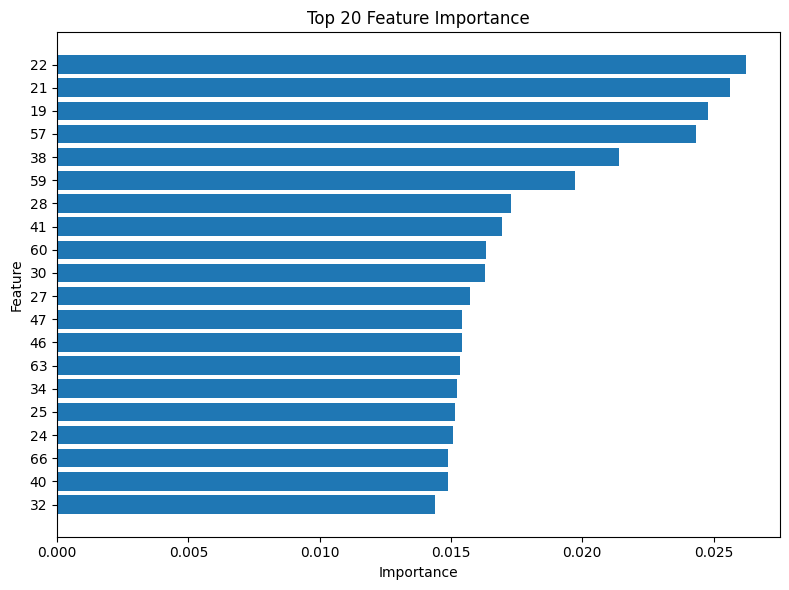

In [208]:
plt.figure(figsize=(8, 6))
plt.barh(top["feature"].astype(str), top["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

In [209]:
# Get the top 20 feature indices
top_features = top["feature"].astype(int).values

# Select only the top 20 features
X_top20 = X_features[:, top_features]

print("Original shape:", X_features.shape)
print("Top 20 features shape:", X_top20.shape)

Original shape: (101916, 76)
Top 20 features shape: (101916, 20)


In [210]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_top20,
    y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (81532, 20)
X_test: (20384, 20)
y_train: (81532, 3)
y_test: (20384, 3)


In [211]:
import numpy as np

# Convert one-hot encoded labels to class labels
y_train_class = np.argmax(y_train, axis=1)
y_test_class = np.argmax(y_test, axis=1)

print("y_train_class:", y_train_class.shape)
print("y_test_class:", y_test_class.shape)
print("Classes:", np.unique(y_train_class))

y_train_class: (81532,)
y_test_class: (20384,)
Classes: [2]


In [212]:
from collections import Counter

print("Training classes:", Counter(y_train_class))
print("Testing classes:", Counter(y_test_class))

Training classes: Counter({np.int64(2): 81532})
Testing classes: Counter({np.int64(2): 20384})


In [213]:
# Check the actual class/label column
labels = y_labels[:, 2]

print("Label shape:", labels.shape)
print("Unique classes:")
print(np.unique(labels))

print("\nClass distribution:")
unique, counts = np.unique(labels, return_counts=True)

for cls, count in zip(unique, counts):
    print(f"{cls}: {count}")

Label shape: (101916,)
Unique classes:
['AD-Auditory' 'ADFSU' 'ADFTD' 'ADSZ' 'APAVA-19']

Class distribution:
AD-Auditory: 30654
ADFSU: 2490
ADFTD: 63783
ADSZ: 633
APAVA-19: 4356


In [214]:
from sklearn.preprocessing import LabelEncoder

# Actual labels
labels = y_labels[:, 2]

# Convert class names to numbers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

print("Classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

print("\nEncoded labels shape:", y.shape)

Classes:
0 -> AD-Auditory
1 -> ADFSU
2 -> ADFTD
3 -> ADSZ
4 -> APAVA-19

Encoded labels shape: (101916,)


In [215]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_top20,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (81532, 20)
X_test: (20384, 20)
y_train: (81532,)
y_test: (20384,)


In [216]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [217]:
y_pred = rf_model.predict(X_test)

print("Prediction completed!")
print("Predictions shape:", y_pred.shape)

Prediction completed!
Predictions shape: (20384,)


In [218]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.985037284144427

Classification Report:
              precision    recall  f1-score   support

 AD-Auditory       0.98      1.00      0.99      6131
       ADFSU       0.75      0.66      0.70       498
       ADFTD       1.00      1.00      1.00     12757
        ADSZ       0.19      0.15      0.17       127
    APAVA-19       1.00      0.99      1.00       871

    accuracy                           0.99     20384
   macro avg       0.79      0.76      0.77     20384
weighted avg       0.98      0.99      0.98     20384



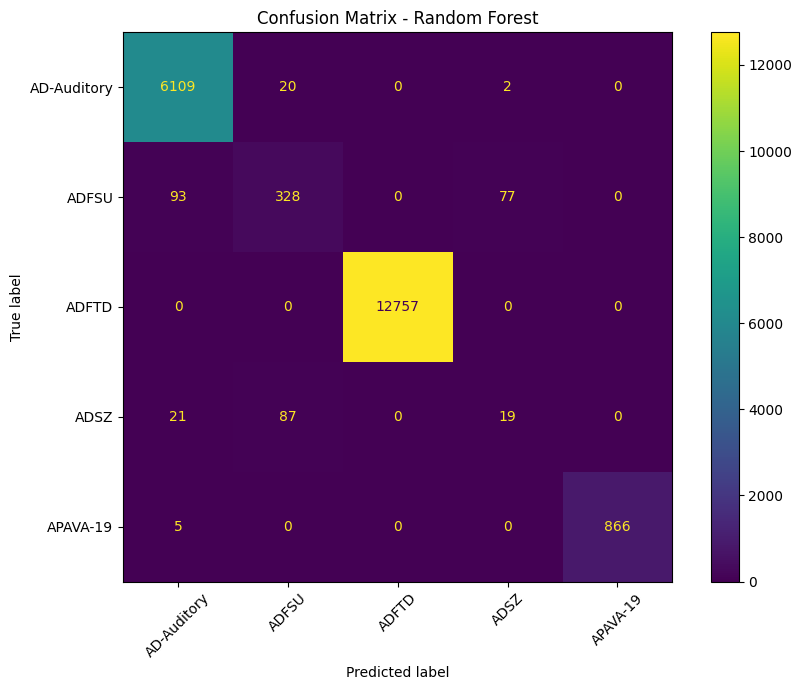

In [219]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
# Get feature importance from the trained Random Forest
feature_importance = rf_model.feature_importances_

# Create a dataframe
importance_df = pd.DataFrame({
    "Feature": top_features,
    "Importance": feature_importance
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

In [ ]:
plt.figure(figsize=(10, 7))

plt.barh(
    importance_df["Feature"].astype(str),
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Top 20 Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("random_forest_top20_importance.png", dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    zero_division=0
)

results = pd.DataFrame({
    "Class": label_encoder.classes_,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support
})

print(results)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Random Forest using all 76 features
rf_all = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_all.fit(X_features, y)

# Predict
y_pred_all = rf_all.predict(X_features)

print("Training accuracy:", accuracy_score(y, y_pred_all))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split all 76 features
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_features,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_all:", X_train_all.shape)
print("X_test_all:", X_test_all.shape)

# Random Forest using all 76 features
rf_all = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train
rf_all.fit(X_train_all, y_train_all)

# Predict on unseen test data
y_pred_all = rf_all.predict(X_test_all)

# Test accuracy
accuracy_all = accuracy_score(y_test_all, y_pred_all)

print("\n76-Feature Test Accuracy:", accuracy_all)

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test_all,
        y_pred_all,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create Random Forest
rf_all = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train using all 76 features
rf_all.fit(X_train_all, y_train_all)

print("Training completed!")

# Predict on TEST data
y_pred_all = rf_all.predict(X_test_all)

print("Prediction completed!")

# Calculate test accuracy
accuracy_all = accuracy_score(y_test_all, y_pred_all)

print("\n76-Feature Test Accuracy:", accuracy_all)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test_all,
        y_pred_all,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:")
print(Counter(y_train))

In [ ]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(Counter(y_train_smote))

print("\nBefore:", X_train.shape)
print("After :", X_train_smote.shape)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest with SMOTE-balanced training data
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train on SMOTE data
rf_smote.fit(X_train_smote, y_train_smote)

print("SMOTE Random Forest training completed!")

In [ ]:
y_pred_smote = rf_smote.predict(X_test)

print("SMOTE Prediction completed!")
print("Predictions shape:", y_pred_smote.shape)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_smote = accuracy_score(y_test, y_pred_smote)

print("SMOTE Test Accuracy:", accuracy_smote)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_smote,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_smote = confusion_matrix(y_test, y_pred_smote)

print("SMOTE Confusion Matrix:")
print(cm_smote)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - Random Forest with SMOTE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig("smote_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Top 20 Features",
        "Random Forest - All 76 Features",
        "Random Forest - Top 20 + SMOTE"
    ],
    "Accuracy": [
        0.985037,
        0.986951,
        0.984841
    ],
    "Macro F1": [
        0.77,
        0.78,
        0.79
    ]
})

print(comparison)